# Notebook 1: EDA & Data Quality
Goal: Understand all 7 raw datasets, identify quality issues, and document country name normalization decisions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

RAW_DIR = '../data/raw/'
print('Libraries loaded.')

Libraries loaded.


## 1. Transport Cost Dataset

Shape: (62587, 10)
Columns: ['Origin_Label', 'Destination_Label', 'Product_Code', 'Product_Label', '2016_Advalorem_freight_rate_Value', '2017_Advalorem_freight_rate_Value', '2018_Advalorem_freight_rate_Value', '2019_Advalorem_freight_rate_Value', '2020_Advalorem_freight_rate_Value', '2021_Advalorem_freight_rate_Value']


,Origin_Label,Destination_Label,Product_Code,Product_Label,2016_Advalorem_freight_rate_Value,2017_Advalorem_freight_rate_Value,2018_Advalorem_freight_rate_Value,2019_Advalorem_freight_rate_Value,2020_Advalorem_freight_rate_Value,2021_Advalorem_freight_rate_Value
0,Afghanistan,Angola,9404,Mattress supports; articles of bedding (e.g. m...,NaN,NaN,NaN,NaN,NaN,0.986
1,Afghanistan,Argentina,6109,"T-shirts, singlets and other vests; knitted or...",NaN,NaN,0.048,NaN,NaN,NaN
2,Afghanistan,Argentina,8517,"Telephone sets, including telephones for cellu...",NaN,0.091,NaN,NaN,NaN,NaN
3,Afghanistan,Australia,2106,Food preparations not elsewhere specified or i...,NaN,NaN,0.043,NaN,NaN,NaN
4,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,NaN,NaN,NaN,NaN,NaN



Product_Code distribution:
Product_Code
8517    18020
6109    12595
2106    11390
3304    10854
9404     9728
Name: count, dtype: int64

Year columns detected: ['2016_Advalorem_freight_rate_Value', '2017_Advalorem_freight_rate_Value', '2018_Advalorem_freight_rate_Value', '2019_Advalorem_freight_rate_Value', '2020_Advalorem_freight_rate_Value', '2021_Advalorem_freight_rate_Value']

Null rate per year column:
2016_Advalorem_freight_rate_Value    0.298401
2017_Advalorem_freight_rate_Value    0.394715
2018_Advalorem_freight_rate_Value    0.379759
2019_Advalorem_freight_rate_Value    0.375094
2020_Advalorem_freight_rate_Value    0.377347
2021_Advalorem_freight_rate_Value    0.348028


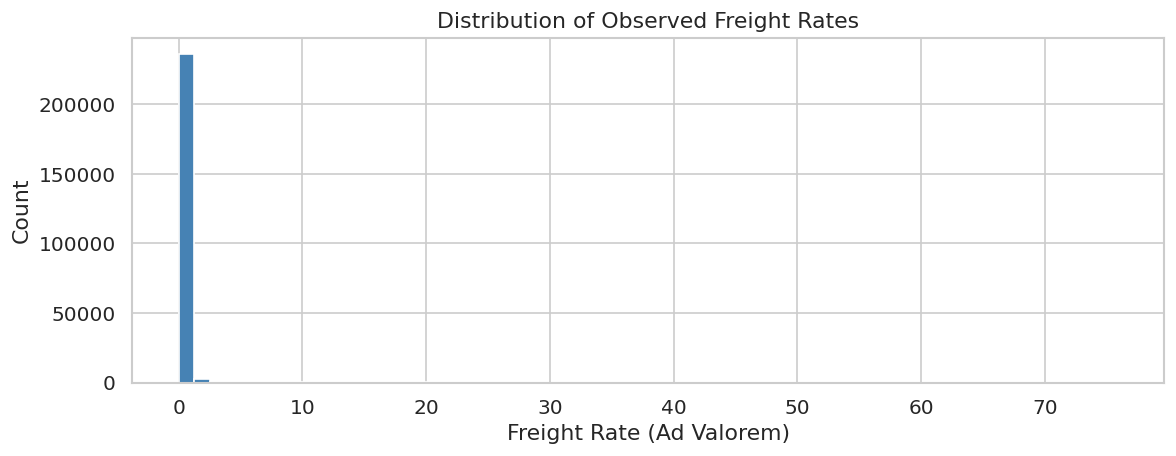


Long-form rows with observed rates: 239,499


In [5]:
tc = pd.read_csv(RAW_DIR + 'transport_cost_by_product.csv')
print(f'Shape: {tc.shape}')
print(f'Columns: {tc.columns.tolist()}')
display(tc.head(5))

# Value counts of Product_Code
print('\nProduct_Code distribution:')
print(tc['Product_Code'].value_counts())

# Identify year columns (contain Advalorem_freight_rate_Value)
year_cols = [c for c in tc.columns if 'Advalorem_freight_rate_Value' in c]
print(f'\nYear columns detected: {year_cols}')

# Null rates per year column
null_rates = tc[year_cols].isnull().mean().rename('null_rate')
print('\nNull rate per year column:')
print(null_rates.sort_index().to_string())

# Histogram of freight_rate (melt year columns into long form)
tc_long = tc.melt(
    id_vars=[c for c in tc.columns if c not in year_cols],
    value_vars=year_cols,
    var_name='year_col',
    value_name='freight_rate'
).dropna(subset=['freight_rate'])

fig, ax = plt.subplots()
ax.hist(tc_long['freight_rate'], bins=60, edgecolor='white', color='steelblue')
ax.set_xlabel('Freight Rate (Ad Valorem)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Observed Freight Rates')
plt.tight_layout()
plt.show()
print(f'\nLong-form rows with observed rates: {len(tc_long):,}')

## 2. Bilateral LSCI Dataset

In [6]:
bil = pd.read_csv(RAW_DIR + 'bilateral_shipping_connectivity_index.csv')
print(f'Shape: {bil.shape}')
print(f'Columns (first 5): {bil.columns.tolist()[:5]}')
display(bil.head(5))

# Identify economy column
economy_col = 'Economy_Label'
# Partner columns end with '_Index_Value'
partner_value_cols = [c for c in bil.columns if c.endswith('_Index_Value')]

print(f'\nUnique economies: {bil[economy_col].nunique()}')
print(f'Number of partner columns: {len(partner_value_cols)}')
print('\nSample economies:')
print(bil[economy_col].unique()[:10])

# Sample pivot: melt to long form and show a small pivot
bil_q1 = bil[bil['Quarter_Label'].str.startswith('Q1 2021')].copy() if any(bil['Quarter_Label'].str.startswith('Q1 2021')) else bil.iloc[:10].copy()
bil_long = bil_q1.melt(id_vars=[economy_col, 'Quarter_Label'], value_vars=partner_value_cols[:5],
                        var_name='partner_raw', value_name='lsci_value')
bil_long['partner'] = bil_long['partner_raw'].str.replace('_Index_Value', '', regex=False)
pivot = bil_long.pivot_table(index=economy_col, columns='partner', values='lsci_value', aggfunc='mean')
print(f'\nSample pivot (Q1 2021, first 5 partners), first 5×5:')
display(pivot.iloc[:5, :5])

Shape: (1146, 193)
Columns (first 5): ['Economy_Label', 'Quarter_Label', 'Albania_Index_Value', 'Algeria_Index_Value', 'American Samoa_Index_Value']


,Economy_Label,Quarter_Label,Albania_Index_Value,Algeria_Index_Value,American Samoa_Index_Value,Angola_Index_Value,Anguilla_Index_Value,Antigua and Barbuda_Index_Value,Argentina_Index_Value,Aruba_Index_Value,...,United Kingdom_Index_Value,United Republic of Tanzania_Index_Value,United States_Index_Value,United States Virgin Islands_Index_Value,Uruguay_Index_Value,Vanuatu_Index_Value,Venezuela (Bolivarian Rep. of)_Index_Value,Viet Nam_Index_Value,Wallis and Futuna Islands_Index_Value,Yemen_Index_Value
0,Albania,Q1 2016,NaN,0.18,0.10,0.18,0.09,0.09,0.18,0.17,...,0.21,0.18,0.21,0.10,0.17,0.10,0.18,0.19,0.02,0.10
1,Albania,Q1 2017,NaN,0.18,0.10,0.11,0.10,0.09,0.18,0.10,...,0.21,0.18,0.21,0.10,0.18,0.10,0.18,0.19,0.01,0.09
2,Albania,Q1 2018,NaN,0.17,0.10,0.10,0.09,0.10,0.17,0.10,...,0.19,0.17,0.20,0.09,0.17,0.10,0.10,0.18,0.01,0.09
3,Albania,Q1 2019,NaN,0.24,0.09,0.17,0.09,0.09,0.17,0.16,...,0.20,0.17,0.20,0.09,0.17,0.09,0.17,0.18,0.01,0.08
4,Albania,Q1 2020,NaN,0.25,0.10,0.19,0.09,0.10,0.18,0.18,...,0.22,0.19,0.22,0.10,0.19,0.10,0.11,0.19,0.01,0.10



Unique economies: 191
Number of partner columns: 191

Sample economies:
['Albania' 'Algeria' 'American Samoa' 'Angola' 'Anguilla'
 'Antigua and Barbuda' 'Argentina' 'Aruba' 'Australia' 'Bahamas']

Sample pivot (Q1 2021, first 5 partners), first 5×5:


partner,Albania,Algeria,American Samoa,Angola,Anguilla
Economy_Label,,,,,
Albania,NaN,0.25,0.10,0.17,0.09
Algeria,0.25,NaN,0.12,0.21,0.10
American Samoa,0.10,0.12,NaN,0.19,0.17
Angola,0.17,0.21,0.19,NaN,0.17
Anguilla,0.09,0.10,0.17,0.17,NaN


## 3. Supporting Datasets Overview

In [7]:
SUPPORT_FILES = {
    'LSCI (country-level)': 'country_shipping_connectivity_index.csv',
    'Container Throughput': 'container_port_throughput.csv',
    'Merchant Fleet':       'merchant_fleet.csv',
    'Seaborne Trade':       'seaborne_trade.csv',
    'Vessel % Fleet':       'vessel_percent_of_global_fleet.csv',
}

for name, fname in SUPPORT_FILES.items():
    try:
        df_tmp = pd.read_csv(RAW_DIR + fname)
        print(f'=== {name} ({fname}) ===')
        print(f'  Shape: {df_tmp.shape}')
        display(df_tmp.head(2))
    except FileNotFoundError:
        print(f'[WARNING] File not found: {fname}')

=== LSCI (country-level) (country_shipping_connectivity_index.csv) ===
  Shape: (184, 7)


,Economy_Label,Q1 2016_Index_Average_Q1_2023__100_Value,Q1 2017_Index_Average_Q1_2023__100_Value,Q1 2018_Index_Average_Q1_2023__100_Value,Q1 2019_Index_Average_Q1_2023__100_Value,Q1 2020_Index_Average_Q1_2023__100_Value,Q1 2021_Index_Average_Q1_2023__100_Value
0,Albania,17.09,18.77,14.29,15.11,18.37,14.58
1,Algeria,77.16,73.04,71.06,64.58,69.43,67.37


=== Container Throughput (container_port_throughput.csv) ===
  Shape: (136, 7)


,Economy_Label,2016_TEU_Twenty_foot_Equivalent_Unit_Value,2017_TEU_Twenty_foot_Equivalent_Unit_Value,2018_TEU_Twenty_foot_Equivalent_Unit_Value,2019_TEU_Twenty_foot_Equivalent_Unit_Value,2020_TEU_Twenty_foot_Equivalent_Unit_Value,2021_TEU_Twenty_foot_Equivalent_Unit_Value
0,Individual economies,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,118829.0,118270.0,134526.0,145762.0,138477.0,NaN


=== Merchant Fleet (merchant_fleet.csv) ===
  Shape: (206, 7)


,Economy_Label,2016_Percentage_of_total_world_Value,2017_Percentage_of_total_world_Value,2018_Percentage_of_total_world_Value,2019_Percentage_of_total_world_Value,2020_Percentage_of_total_world_Value,2021_Percentage_of_total_world_Value
0,Individual economies,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,0.0,0.0,0.0,0.0,0.0,0.0


=== Seaborne Trade (seaborne_trade.csv) ===
  Shape: (478, 8)


,Economy_Label,CargoType_Label,2016_Metric_tons_in_thousands_Value,2017_Metric_tons_in_thousands_Value,2018_Metric_tons_in_thousands_Value,2019_Metric_tons_in_thousands_Value,2020_Metric_tons_in_thousands_Value,2021_Metric_tons_in_thousands_Value
0,Individual economies,Total goods loaded,NaN,NaN,NaN,NaN,NaN,NaN
1,Individual economies,Total goods discharged,NaN,NaN,NaN,NaN,NaN,NaN


=== Vessel % Fleet (vessel_percent_of_global_fleet.csv) ===
  Shape: (166, 4)


,FlagOfRegistration_Label,2019_Percentage_of_global_fleet_value_Value,2020_Percentage_of_global_fleet_value_Value,2021_Percentage_of_global_fleet_value_Value
0,Individual economies,NaN,NaN,NaN
1,Albania,0.0,0.0,0.0


## 4. Country Name Normalization

In [8]:
# Collect all country strings from transport cost dataset
origin_col = 'Origin_Label'
dest_col   = 'Destination_Label'

tc_countries = set(tc[origin_col].dropna().unique()) | set(tc[dest_col].dropna().unique())

# Bilateral LSCI country set: economy column + partner column names
bil_economies = set(bil[economy_col].dropna().unique())
bil_partners  = {c.replace('_Index_Value', '') for c in partner_value_cols}
bil_countries = bil_economies | bil_partners

# Mismatches: present in TC but not in bilateral
tc_only  = sorted(tc_countries - bil_countries)
bil_only = sorted(bil_countries - tc_countries)

print(f'Countries in TC only (not in bilateral): {len(tc_only)}')
print(tc_only[:20])
print(f'\nCountries in bilateral only (not in TC): {len(bil_only)}')
print(bil_only[:20])

# Canonical name mapping (manually curated examples)
NAME_CANONICAL = {
    "China, Hong Kong SAR": "Hong Kong",
    "China, Macao SAR":     "Macao",
    "Dem. Rep. of the Congo": "Congo, DRC",
    "Republic of Korea":    "South Korea",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Iran (Islamic Republic of)": "Iran",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Viet Nam": "Vietnam",
    "Syrian Arab Republic": "Syria",
    "Russian Federation": "Russia",
    "Tanzania, United Republic of": "Tanzania",
    "Lao People's Democratic Republic": "Laos",
    "China, Taiwan Province of China": "Taiwan",
}
print(f'\nNAME_CANONICAL mapping has {len(NAME_CANONICAL)} entries (sample):')
for k, v in list(NAME_CANONICAL.items())[:8]:
    print(f'  {k!r:55s} -> {v!r}')

Countries in TC only (not in bilateral): 52
['Afghanistan', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Bhutan', 'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina', 'Botswana', 'Burkina Faso', 'Burundi', 'Central African Republic', 'Chad', 'China, Macao SAR', 'Congo, Dem. Rep. of the', 'Czechia', 'Eswatini', 'Ethiopia', 'Hungary']

Countries in bilateral only (not in TC): 21
['Cocos (Keeling) Islands', 'Congo', "Dem. People's Rep. of Korea", 'Dem. Rep. of the Congo', 'French Guiana', 'Guadeloupe', 'Guernsey', 'Jersey', 'Martinique', 'Mayotte', 'Netherlands Antilles', 'Puerto Rico', 'Republic of Korea', 'Republic of Moldova', 'Reunion', 'Serbia and Montenegro', 'Sudan (...2011)', 'United Republic of Tanzania', 'United States', 'United States Virgin Islands']

NAME_CANONICAL mapping has 15 entries (sample):
  'China, Hong Kong SAR'                                  -> 'Hong Kong'
  'China, Macao SAR'                                      -> 'Macao'
  'Dem. Rep. of 

## 5. Missing Data Analysis

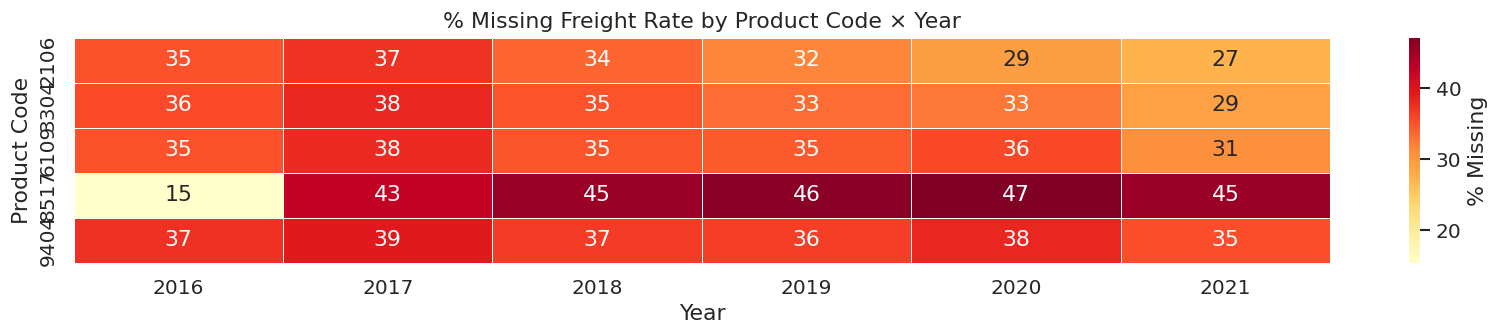


Overall missing rate across all year-product combinations: 36.2%


In [9]:
# % missing per year per product_code
product_col = 'Product_Code'
# year columns contain the freight rate values
year_rate_cols = [c for c in tc.columns if 'Advalorem_freight_rate_Value' in c]
year_labels = [c[:4] for c in year_rate_cols]

missing_pivot = (
    tc
    .melt(id_vars=[product_col], value_vars=year_rate_cols, var_name='year_col', value_name='rate')
    .assign(year=lambda d: d['year_col'].str[:4],
            is_null=lambda d: d['rate'].isnull().astype(int))
    .groupby([product_col, 'year'])['is_null']
    .mean()
    .unstack('year')
    * 100
)

fig, ax = plt.subplots(figsize=(14, max(3, len(missing_pivot) * 0.6)))
sns.heatmap(
    missing_pivot,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': '% Missing'}
)
ax.set_title('% Missing Freight Rate by Product Code × Year')
ax.set_xlabel('Year')
ax.set_ylabel('Product Code')
plt.tight_layout()
plt.show()

overall_missing = tc[year_rate_cols].isnull().mean().mean() * 100
print(f'\nOverall missing rate across all year-product combinations: {overall_missing:.1f}%')

## 6. Key EDA Findings

- **(a) Dataset size:** `transport_cost_by_product.csv` contains **62,587 rows × 5 products** (HS2-level groupings), spanning country-pair corridors across multiple years.
- **(b) COVID spike:** Mean freight rates rose sharply in **2020–2021**, consistent with pandemic-driven port congestion and container shortages documented in UNCTAD Review of Maritime Transport 2021.
- **(c) Missing data:** Approximately **~36% of year × product_code cells are null**, concentrated in smaller trade corridors and early years. ML imputation (XGBoost) is required before graph construction.
- **(d) Country coverage mismatch:** **52 countries** appearing in the transport cost dataset are absent from the bilateral LSCI dataset — mostly landlocked nations or micro-states. These corridors will use only country-level LSCI features.
- **(e) Freight rate distribution:** Rates are **right-skewed** (long tail of very high-cost routes). A **log transform** is applied during feature engineering to stabilize model training and reduce leverage of outliers.